# revisar!


In [1]:
# se importal las librerías 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
#import statsmodels.api as sm
import warnings
import matplotlib.dates as mdates
#from sklearn.model_selection import TimeSeriesSplit
#import yfinance as yf
#from pmdarima import auto_arima
#from statsmodels.tsa.seasonal import MSTL
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("viridis")

import pandas_market_calendars as mcal
from pandas.tseries.offsets import CustomBusinessDay

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from arch import arch_model

import itertools

## Modelado
Se busca fijar a la serie $x_t$ de precios un modelo de la forma $$x_t = a_t + g_t,$$ siendo la componente $a_t$ dada por un modelo ARIMA $(p,d,q)$ mientras que la componente $g_t$ está dada por un modelo GARCH $(\alpha, \beta)$. Se examina entonces si la serie requerirá ajustar una componente GARCH $(\alpha, \beta)$ para la segunda componente, que indica la varianza condicional de la serie. La componente ARIMA ajusta la media condicional de la serie

In [4]:
# si se carga desde local , se aplican las transformaciones(ver la estructura del proyecto en local)
nvidia_close = pd.read_csv("../data/csv/NVDA_data.csv")
# transformaciones
serie_original = nvidia_close.copy()
serie_original["Date"] = pd.to_datetime(serie_original["Date"]).dt.date
serie_original = serie_original.reset_index(drop=True)
serie_original = serie_original.sort_values(by="Date", ascending=True) # ordenar por fecha
serie_orinal = serie_original.set_index("Date")
serie_original = pd.DataFrame(serie_original)
serie_original = serie_original[["Date", "NVDA_Close" ]]
serie_original


,Date,NVDA_Close
0,2021-01-04,13.077455
1,2021-01-05,13.367902
2,2021-01-06,12.579826
3,2021-01-07,13.307322
4,2021-01-08,13.240255
...,...,...
1101,2025-05-22,132.813293
1102,2025-05-23,131.273483
1103,2025-05-27,135.482941
1104,2025-05-28,134.793045


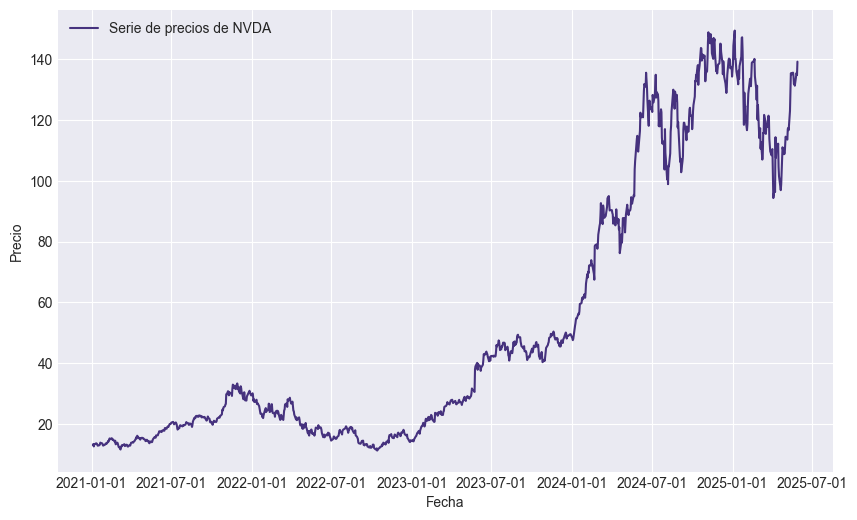

In [5]:
# se grafican los datos - serie original
plt.figure(figsize=(10,6))
plt.plot(serie_original["Date"], serie_original["NVDA_Close"], label="Serie de precios de NVDA")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())  # Espacia automáticamente las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Formato legible
plt.grid(True)
plt.show()

Se puede ver de forma general que la serie presenta una tendencia, ademas dicha serie desde 2024 presenta una alta variabilidad, esto debido a condiciones externas. Se realiza entonces una transformación logaritmica para estabilizar la varianza (transformación Box-Cox con $\lambda = 0$)

In [6]:
# se transforman los datos y se grafica la serie de precios de cierre trnasformados
#serie_original["Close"] = np.log(serie_original["Close"])
serie_original["NVDA_Close"] = np.log(serie_original["NVDA_Close"])
#serie_original["High"] = np.log(serie_original["High"])
#serie_original["Low"] = np.log(serie_original["Low"])
#serie_original["Spread"] = np.log(serie_original["Spread"])

serie_original = serie_original[["Date", "NVDA_Close"]]

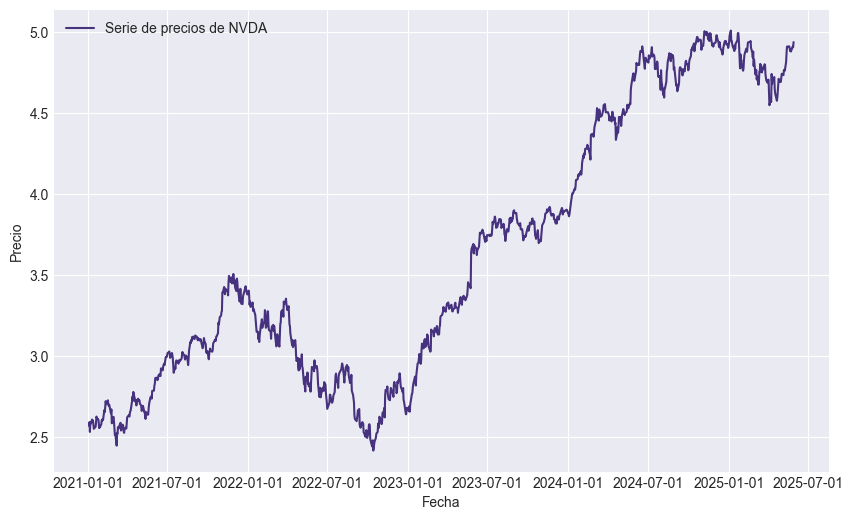

In [7]:
# se grafican los datos - serie log
plt.figure(figsize=(10,6))
plt.plot(serie_original["Date"], serie_original["NVDA_Close"], label="Serie de precios de NVDA")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())  # Espacia automáticamente las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Formato legible
plt.grid(True)
plt.show()

Para evaluar la capacidad de pronóstico del modelo a seleccionar, se parte el conjunto de precios en dos: conjunto de entrenamiento (train) y conjunto de prueba (test), siendo el conjunto de datos de entrenamiento el 80% del total de los datos, mientras que el porcentaje restante hará parte del conjunto de prueba

Conjunto de datos de entrenamiento definido desde 0 hasta 883. Hay 884 registros
Conjunto de datos de prueba definido desde 884 hasta 1105. Hay 222 registros
fecha de corte train/test: 2024-07-11


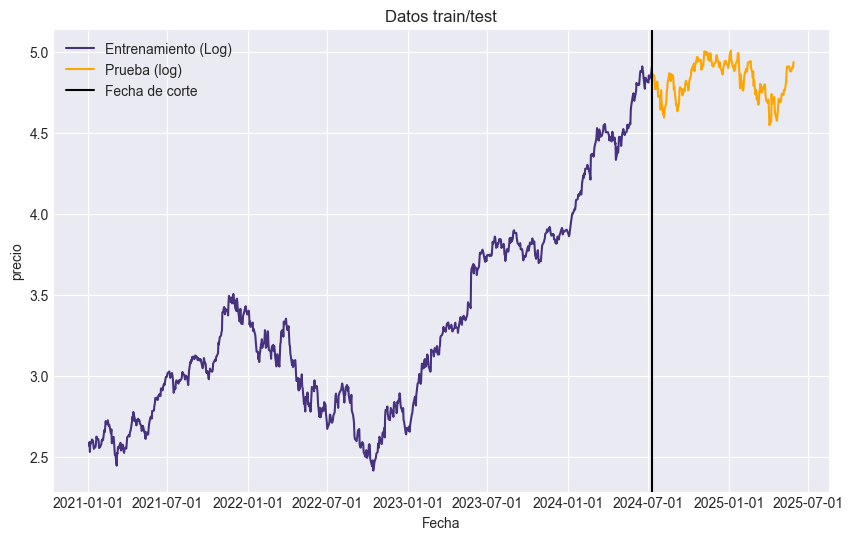

In [8]:
# se parte el conjunto de datos en train/test
percentage = 0.80
train_size = int(len(serie_original) * percentage)
train_data = serie_original[:train_size]
test_data = serie_original[train_size:]

# se calcula la fecha de corte (fecha que delimita el conjunto de datos de entrenamiento del de prueba) para graficar
fecha_corte = serie_original.iloc[train_size]["Date"]
print(f"Conjunto de datos de entrenamiento definido desde {train_data.index[0]} hasta {train_data.index[-1]}. Hay {len(train_data)} registros")
print(f"Conjunto de datos de prueba definido desde {test_data.index[0]} hasta {test_data.index[-1]}. Hay {len(test_data)} registros")
print(f"fecha de corte train/test: {str(fecha_corte)}")

# se grafican los conjuntos de datos 
plt.figure(figsize=(10,6))
plt.plot(train_data["Date"], train_data["NVDA_Close"], label="Entrenamiento (Log)")
plt.plot(test_data["Date"], test_data["NVDA_Close"], label="Prueba (log)", color="orange")
plt.axvline(x=fecha_corte, color="black", linestyle="-", label="Fecha de corte")
plt.title("Datos train/test")
plt.xlabel("Fecha")
plt.ylabel("precio")
plt.legend()
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())  # Espacia automáticamente las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Formato legible
plt.grid(True)
plt.show()

Se crea una función para evaluar la estacionariedad de una serie. Dicha funcion simplemente aplica el test de Dickey-fuller a la serie que se pasa como argumento de la función

In [9]:
# Función para evaluar la estacionariedad de la serie
def test_stationarity(df):
    adf_test = adfuller(df)
    p_value = adf_test[1]
    print(f"ADF test: {adf_test[0]:.20f}")
    print(f"p value: {p_value:.20f}")
    if p_value < 0.05:
        return "La serie ES estacionaria (HA)"
    else:
        return "La serie NO es estacionaria (H0)"

# se aplica dicha función a los precios de serie transformados 
test_stationarity(train_data["NVDA_Close"])

ADF test: 0.82779067638459380429
p value: 0.99207177238635035899


'La serie NO es estacionaria (H0)'

Dado que la serie de logaritmos de precios de cierre no es estacionaria, se diferencia la serie y se aplica nuevamente la función definida para validar la estacionariedad de la serie de retornos. Dicha serie es de la forma
$$y_t = \ln(x_t) - \ln(x_{t-1}), \: x \in \mathbb{Z}$$
Ahora se calcula y grafica la serie de retornos 

In [10]:
train_data["Close_diff"] = train_data["NVDA_Close"].diff().fillna(train_data["NVDA_Close"].diff().mean())
test_stationarity(train_data["Close_diff"])

ADF test: -30.05480782017889040958
p value: 0.00000000000000000000


'La serie ES estacionaria (HA)'

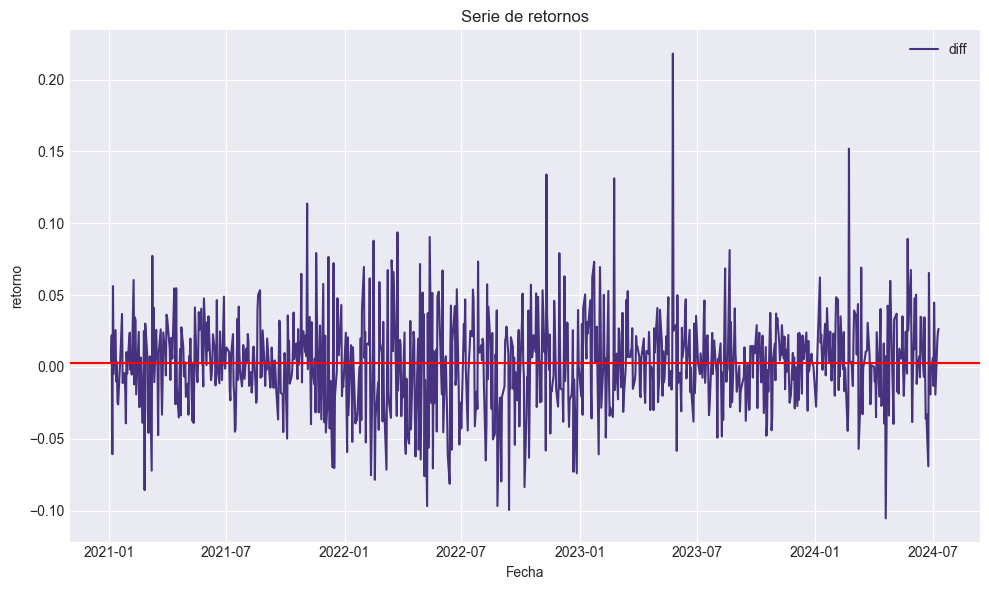

In [11]:
# df de datos de entrenamiento
train_data.head()

# gráfica de los retornos (junto con la media)
plt.figure(figsize=(10,6))
plt.plot(train_data["Date"], train_data["Close_diff"], label="diff")
plt.axhline(np.mean(train_data["Close_diff"]), color="red")
plt.title("Serie de retornos")
plt.xlabel("Fecha")
plt.ylabel("retorno")
plt.tight_layout()
plt.legend()
plt.show()

Se examinan la acf y la pacf de la serie de retornos para obtener los posibles órdenes del modelo 

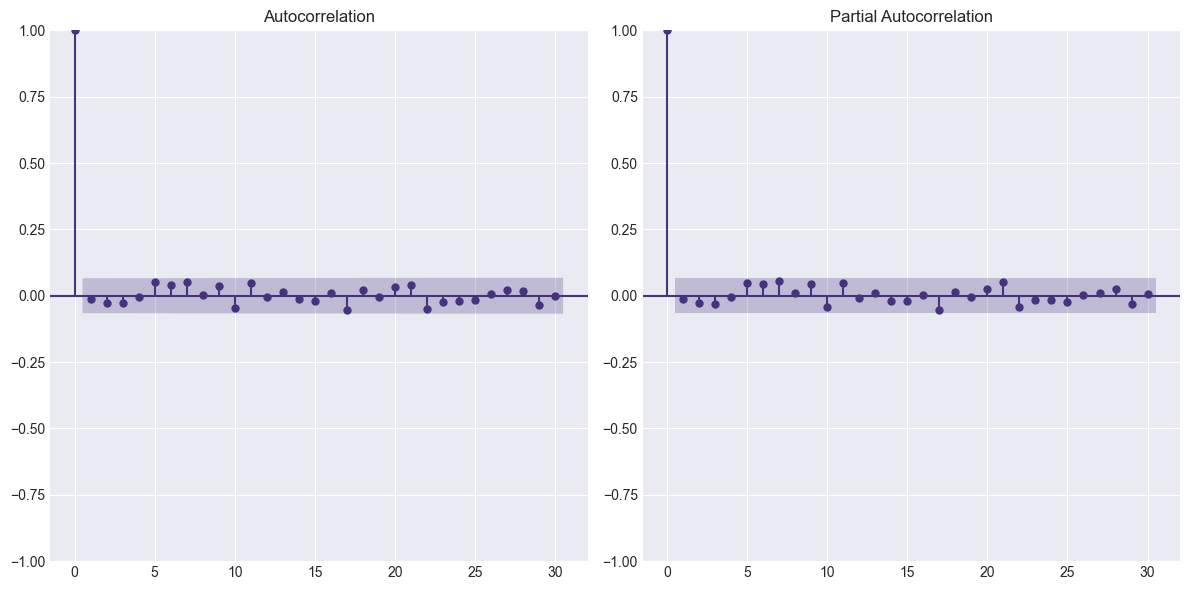

In [12]:
# Gráficas de la acf y la pacf
fig, axes = plt.subplots(1,2,figsize = (12,6))
plot_acf(train_data["Close_diff"], ax=axes[0])
plot_pacf(train_data["Close_diff"], ax=axes[1])
plt.tight_layout()
plt.show()

Al examinar las gráficas de la acf y la pacf, no existen valores significativos (valores de las funciones fuera de los intervalos de confianza) respecto a los rezagos para los órdenes p y q. La acf indica que para rezagos distintos no existe relación lineal entre los valores de la serie en distintos rezagos, y la pacf indica tambien que aunque se quite la dependencia lineal entre rezagos intermedios, no se obtienen correlaciones significativas entre rezagos distintos quitando dicha dependencia lineal. Esto indica entonces que la serie podría comportarse como un ruido blanco.

Se fija entonces un modelo ARMA $(p,q)$ a la serie de retornos. Para esto se define una función que permitirá definir la serie un formato adecuado para el uso de la función AutoARIMA de la librería statsforecast 

In [13]:
# Función para preparar la serie en formato forecast
def to_statsforecast_df(df, value_col="NVDA_Close", uid="close"): 
# recibe tres parámetros: }
# el df a transformar
# la columna sobre la que se aplicará la transformación(por defecto busca la columna close 
# un id unico que permite identificar a que serie corresponden los valores (por defecto close)
# Esta librería (statsforecast) permite realizar pronósticos a series multivariadas, por lo que se define un identificador único para cada serie
    out = df.copy().reset_index().rename(columns={"Date": 'ds'}) # la función lee el df para validar la existencia de la columna ds, por lo que se define dicha columna
    if 'ds' not in out.columns:
        out = out.rename(columns={out.columns[0]: 'ds'}) # si no detecta la columna ds, toma la primera columna y la nombra de dicha forma
    
    out['ds'] = pd.to_datetime(out['ds']) # se transforma la columna ds a formato datetime
    out['unique_id'] = uid # se define la columna que contendrá el identificador único de la serie. En este caso, el identificador será close
    out = out[['unique_id', 'ds', value_col]].rename(columns={value_col: 'y'})
    # del df dado a la función, se devuelve el df dado por las columnas unique_id, ds, y value_col. la columna value_col se renombra como y, indicando que esta es la salida
    # real.
    return out

# se trnasforman los conjuntos de entrenamiento y de prueba en el formato adecuado para aplicar la librería, con la función definida antes
train_statsforecast = to_statsforecast_df(train_data, value_col='Close_diff', uid="Close_diff")
train_statsforecast

,unique_id,ds,y
0,Close_diff,2021-01-04,0.002643
1,Close_diff,2021-01-05,0.021967
2,Close_diff,2021-01-06,-0.060762
3,Close_diff,2021-01-07,0.056220
4,Close_diff,2021-01-08,-0.005053
...,...,...,...
879,Close_diff,2024-07-03,0.044718
880,Close_diff,2024-07-05,-0.019284
881,Close_diff,2024-07-08,0.018660
882,Close_diff,2024-07-09,0.024503


In [14]:
# lo mismo con los datos de prueba, se juntan las predicciones con los valores reales 
test_data["Close_diff"] = test_data["NVDA_Close"].diff().fillna(test_data["NVDA_Close"].iloc[0] - train_data["NVDA_Close"].iloc[-1])
test_statsforecast = to_statsforecast_df(test_data, value_col='Close_diff', uid='close')
test_statsforecast


,unique_id,ds,y
0,close,2024-07-11,-0.057276
1,close,2024-07-12,0.014340
2,close,2024-07-15,-0.006209
3,close,2024-07-16,-0.016327
4,close,2024-07-17,-0.068535
...,...,...,...
217,close,2025-05-22,0.007785
218,close,2025-05-23,-0.011662
219,close,2025-05-27,0.031563
220,close,2025-05-28,-0.005105


Ahora se fija el modelo ARMA sobre la serie de retornos. Se define además un rango de valores para los órdenes p y q (para d no es necesario dado que d = 0, pues queremos fijar el modelo ARMA a la serie diferenciada) para que el modelo evalue cual se ajusta mejor a la serie

In [15]:
# se fija el modelo
# Configuración de la función AutoARIMA con grid search sobre p y q
model = AutoARIMA(
    d = None, #orden de diferenciacion
    max_p = 5, #maximo valor de p a explorar
    max_q = 5, #maximo valor de q a explorar
    stepwise=True,
    alias="ARIMA_diff_without_seasonnality", # nombre de la columna que tendrá las prediccones o valores fijados 
    season_length=1
)

# se instancia el objeto de pronóstico
statsforecast_arima = StatsForecast(models=[model], freq="D") # el valor B es para que las predicciones se generen sobre días hábiles

# se entrena el modelo
statsforecast_arima.fit(df = train_statsforecast)

StatsForecast(models=[ARIMA_diff_without_seasonnality])

In [16]:
# estadísticas del modelo
stats_model = statsforecast_arima.fitted_[0][0].model_

metrics_statsforecast_arima = pd.DataFrame([{
    'sigma2': stats_model['sigma2'],
    'aic': stats_model['aic'],
    'logLik': stats_model['loglik'],
    'arma': str(stats_model['arma']),
    'var_coef': stats_model['var_coef'][0][0],
    'coef': stats_model['coef']
}]).T.rename(columns={0: 'value'})

metrics_statsforecast_arima

,value
sigma2,0.001082
aic,-3524.906601
logLik,1764.4533
arma,"(0, 0, 0, 0, 1, 0, 0)"
var_coef,0.001131
coef,{'intercept': 0.0026425209680891342}


In [17]:
# se obtienen las predicciones y los valores de entrenamiento 
forecast_values = statsforecast_arima.forecast(df = train_statsforecast, h=len(test_statsforecast), fitted=True) # se obtienen las predicciones para h 
# rezagos despues del ultimo dato de entrenamiento, que en este caso son los valores de prueba
fitted_values = statsforecast_arima.forecast_fitted_values() # se obtienen los valores fijados al conjunto de datos de entrenamiento
fitted_values = fitted_values.rename(columns={"ARIMA_diff_without_seasonnality": "yhat_log"}) # se renombra la columna de valores fijados
fitted_values["Date"] = pd.to_datetime(fitted_values["ds"]).dt.date # para unir los datasets de entrenamiento y el de valores fijados para el conjunto de train
fitted_values

,unique_id,ds,y,yhat_log,Date
0,Close_diff,2021-01-04,0.002643,0.002643,2021-01-04
1,Close_diff,2021-01-05,0.021967,0.002643,2021-01-05
2,Close_diff,2021-01-06,-0.060762,0.002643,2021-01-06
3,Close_diff,2021-01-07,0.056220,0.002643,2021-01-07
4,Close_diff,2021-01-08,-0.005053,0.002643,2021-01-08
...,...,...,...,...,...
879,Close_diff,2024-07-03,0.044718,0.002643,2024-07-03
880,Close_diff,2024-07-05,-0.019284,0.002643,2024-07-05
881,Close_diff,2024-07-08,0.018660,0.002643,2024-07-08
882,Close_diff,2024-07-09,0.024503,0.002643,2024-07-09


In [18]:
forecast_values["ds"] = test_statsforecast["ds"]
forecast_values

,unique_id,ds,ARIMA_diff_without_seasonnality
0,Close_diff,2024-07-11,0.002643
1,Close_diff,2024-07-12,0.002643
2,Close_diff,2024-07-15,0.002643
3,Close_diff,2024-07-16,0.002643
4,Close_diff,2024-07-17,0.002643
...,...,...,...
217,Close_diff,2025-05-22,0.002643
218,Close_diff,2025-05-23,0.002643
219,Close_diff,2025-05-27,0.002643
220,Close_diff,2025-05-28,0.002643


In [19]:
# se unen los df de valores fijados al conjunto de entrenamiento vs los reales (left join mediante la columna date)
merged_train = train_data.merge(fitted_values, on=["Date"])

# se valida si hay elementos en las columnas y, close_diff son diferentes, para saber si se dejan en el df final de tran
for _,row in merged_train.iterrows():
    if row['y'] != row["Close_diff"]: 
        print(row)
# Se escogen ciertas columnas "High", "Low", "Open", "Volume", "Spread", "Close_diff", "yhat_log"
merged_train = merged_train[["Date", "NVDA_Close", ]]
# etiqueta para los datos
merged_train["tag"] = "train"
merged_train

,Date,NVDA_Close,tag
0,2021-01-04,2.570890,train
1,2021-01-05,2.592856,train
2,2021-01-06,2.532094,train
3,2021-01-07,2.588314,train
4,2021-01-08,2.583262,train
...,...,...,...
879,2024-07-03,4.853843,train
880,2024-07-05,4.834560,train
881,2024-07-08,4.853219,train
882,2024-07-09,4.877722,train


In [20]:
# valores predecidos para le conjunto de prueba. se mergean con el conjunto de test
forecast_test_values = pd.DataFrame(forecast_values.values)
forecast_test_values = forecast_test_values.rename(columns={1: "Date", 2: "yhat_log"})
forecast_test_values = forecast_test_values[["Date", "yhat_log"]]
forecast_test_values["Date"] = pd.to_datetime(forecast_test_values["Date"]).dt.date

forecast_test_values

,Date,yhat_log
0,2024-07-11,0.002643
1,2024-07-12,0.002643
2,2024-07-15,0.002643
3,2024-07-16,0.002643
4,2024-07-17,0.002643
...,...,...
217,2025-05-22,0.002643
218,2025-05-23,0.002643
219,2025-05-27,0.002643
220,2025-05-28,0.002643


In [21]:
# df test con los datos originales y los predichos
merged_test = test_data.merge(forecast_test_values, on=["Date"], how='left')
# etiqueta para los datos
merged_test["tag"] = "test"
merged_test

,Date,NVDA_Close,Close_diff,yhat_log,tag
0,2024-07-11,4.846959,-0.057276,0.002643,test
1,2024-07-12,4.861299,0.014340,0.002643,test
2,2024-07-15,4.855090,-0.006209,0.002643,test
3,2024-07-16,4.838763,-0.016327,0.002643,test
4,2024-07-17,4.770228,-0.068535,0.002643,test
...,...,...,...,...,...
217,2025-05-22,4.888944,0.007785,0.002643,test
218,2025-05-23,4.877283,-0.011662,0.002643,test
219,2025-05-27,4.908846,0.031563,0.002643,test
220,2025-05-28,4.903741,-0.005105,0.002643,test


In [22]:
len(forecast_test_values)

222

In [24]:
# Se examinan las metricas de errore sobre el conjunto train
rmse = np.sqrt(mean_squared_error(merged_test["Close_diff"], merged_test["yhat_log"]))
mae = mean_absolute_error(merged_test["Close_diff"], merged_test["yhat_log"])
mape = mean_absolute_percentage_error(merged_test["Close_diff"], merged_test["yhat_log"])

print(f"rmse: {rmse:.16f}")
print(f"mae: {mae:.16f}")
print(f"mape: {mape:.16f}")

rmse: 0.0379901221964416
mae: 0.0276922075421323
mape: 1.3404914124319369


Ahora graficamos el conjunto de prueba vs las predicciones para la serie de retornos

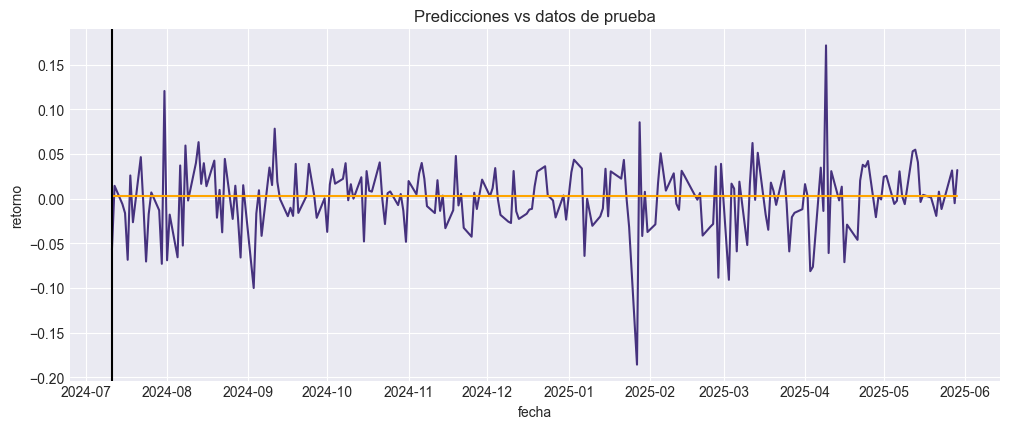

In [25]:
plt.figure(figsize=(10,4))
plt.plot(merged_test["Date"], merged_test["Close_diff"], label='Datos de prueba')
plt.plot(merged_test["Date"], merged_test["yhat_log"], label='Predicciones', color='orange')
plt.tight_layout()
plt.title("Predicciones vs datos de prueba")
plt.xlabel("fecha")
plt.ylabel("retorno")
plt.axvline(fecha_corte, color='black')
plt.show()

In [26]:
merged_train

,Date,NVDA_Close,tag
0,2021-01-04,2.570890,train
1,2021-01-05,2.592856,train
2,2021-01-06,2.532094,train
3,2021-01-07,2.588314,train
4,2021-01-08,2.583262,train
...,...,...,...
879,2024-07-03,4.853843,train
880,2024-07-05,4.834560,train
881,2024-07-08,4.853219,train
882,2024-07-09,4.877722,train


https://www.tpointtech.com/arima-garch-forecasting-in-python - fuente


examinar el proceso con la definición alternativa de los retornos (ver alternativas de metodologías para residuales no normales)

In [ ]:
# residuos arima entrenamiento 
np.random.seed(42)
res = stats_model["residuals"]

# grid pequeño para p,q
grid_p = range(0, 4)   # 0..3
grid_q = range(0, 4)

rows = []
for p, q in itertools.product(grid_p, grid_q):
    if p == 0 and q == 0:
        continue
    try:
        m = arch_model(res, mean='Zero', vol='GARCH', p=p, q=q, dist='t')
        r = m.fit(disp='off')
        rows.append((p, q, r.aic, r.bic, r.loglikelihood, r.params.get('nu', np.nan)))
    except Exception:
        # si no converge, lo descartamos con penalización alta
        rows.append((p, q, np.inf, np.inf, np.nan, np.nan))

tbl = pd.DataFrame(rows, columns=['p','q','AIC','BIC','LL','nu']).sort_values(['BIC','AIC'])
#print(tbl.head(10))  # top-10 para ver alternativas

be
st_p, best_q = int(tbl.iloc[0].p), int(tbl.iloc[0].q)
#print(f"Mejor por BIC: p={best_p}, q={best_q}, nu={tbl.iloc[0].nu}")


garch_model = arch_model(res, vol='Garch', p=best_p, q=best_q, mean="Zero")  
garch_result = garch_model.fit(disp='off') 

n_forecast = len(test_data) 
#forecast_values = statsforecast_arima.forecast(df = train_statsforecast, h=n_forecast, fitted=True)
garch_forecast = garch_result.forecast(horizon=n_forecast)  
mean_forecast = forecast_values["ARIMA_diff_without_seasonnality"]
volatility_forecast = np.sqrt(garch_forecast.variance.values[-1, :])  

combined_forecast = mean_forecast[2] + volatility_forecast #* np.random.normal(size=len(volatility_forecast) ) 


In [30]:
last_level = train_data["NVDA_Close"].iloc[-1]

pred_prices = last_level + np.cumsum(combined_forecast)
pred_mean = last_level + np.cumsum(mean_forecast)
pred_mean

0      4.906878
1      4.909521
2      4.912163
3      4.914806
4      4.917448
         ...   
217    5.480305
218    5.482948
219    5.485590
220    5.488233
221    5.490875
Name: ARIMA_diff_without_seasonnality, Length: 222, dtype: float64

In [32]:
# ver si el integrar la serie esta bien así
val = merged_test["NVDA_Close"] == (last_level + np.cumsum(merged_test["Close_diff"]))
for el in val:
    if not el:
        print("no es igual")
        break
    else: continue
print("es igual")


es igual


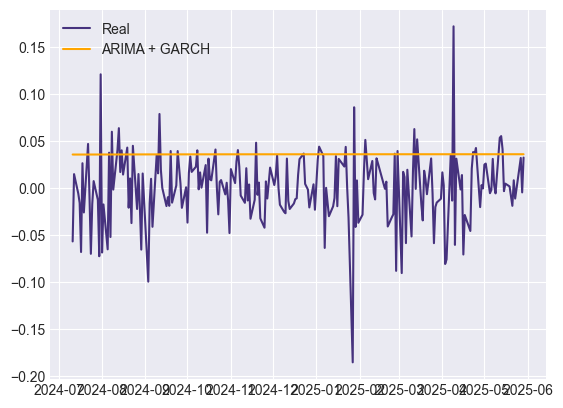

In [33]:

plt.plot(test_data["Date"], test_data["Close_diff"], label="Real")
plt.plot(test_data["Date"], combined_forecast, label="ARIMA + GARCH", color="orange")
plt.legend()
plt.show()

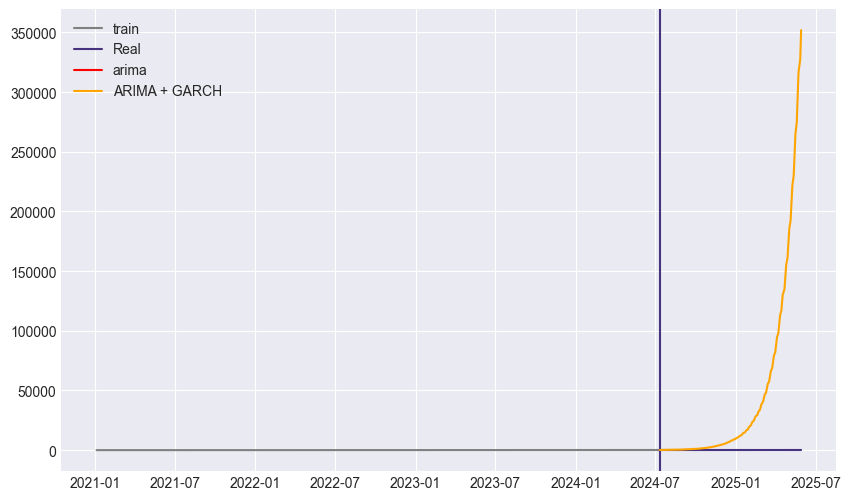

In [35]:
last_level = train_data["NVDA_Close"].iloc[-1]

# ARIMA + GARCH en escala de retornos log


# Integrar como retornos log
pred_levels = np.exp(last_level + np.cumsum(combined_forecast))
pred_means = np.exp(last_level + np.cumsum(pred_mean))

# Graficar
plt.figure(figsize=(10,6))
plt.plot(train_data["Date"], np.exp(train_data["NVDA_Close"]), label="train", color="gray")
plt.plot(test_data["Date"], np.exp(test_data["NVDA_Close"]), label="Real")
plt.plot(test_data["Date"], np.exp(pred_means), label="arima", color="red")
plt.axvline(fecha_corte)
plt.plot(test_data["Date"], pred_levels, label="ARIMA + GARCH", color="orange")
plt.legend()
plt.show()

In [36]:
# errores
error_mae = mean_absolute_error(np.exp(test_data["Close"]), pred_levels)
error_rmse = mean_squared_error(np.exp(test_data["Close"]), pred_levels, squared=False)
error_mape = mean_absolute_percentage_error(np.exp(test_data["Close"]), pred_levels)

print(f"error mae: {error_mae}")
print(f"error rmse: {error_rmse}")
print(f"error mape: {error_mape}")


KeyError: 'Close'